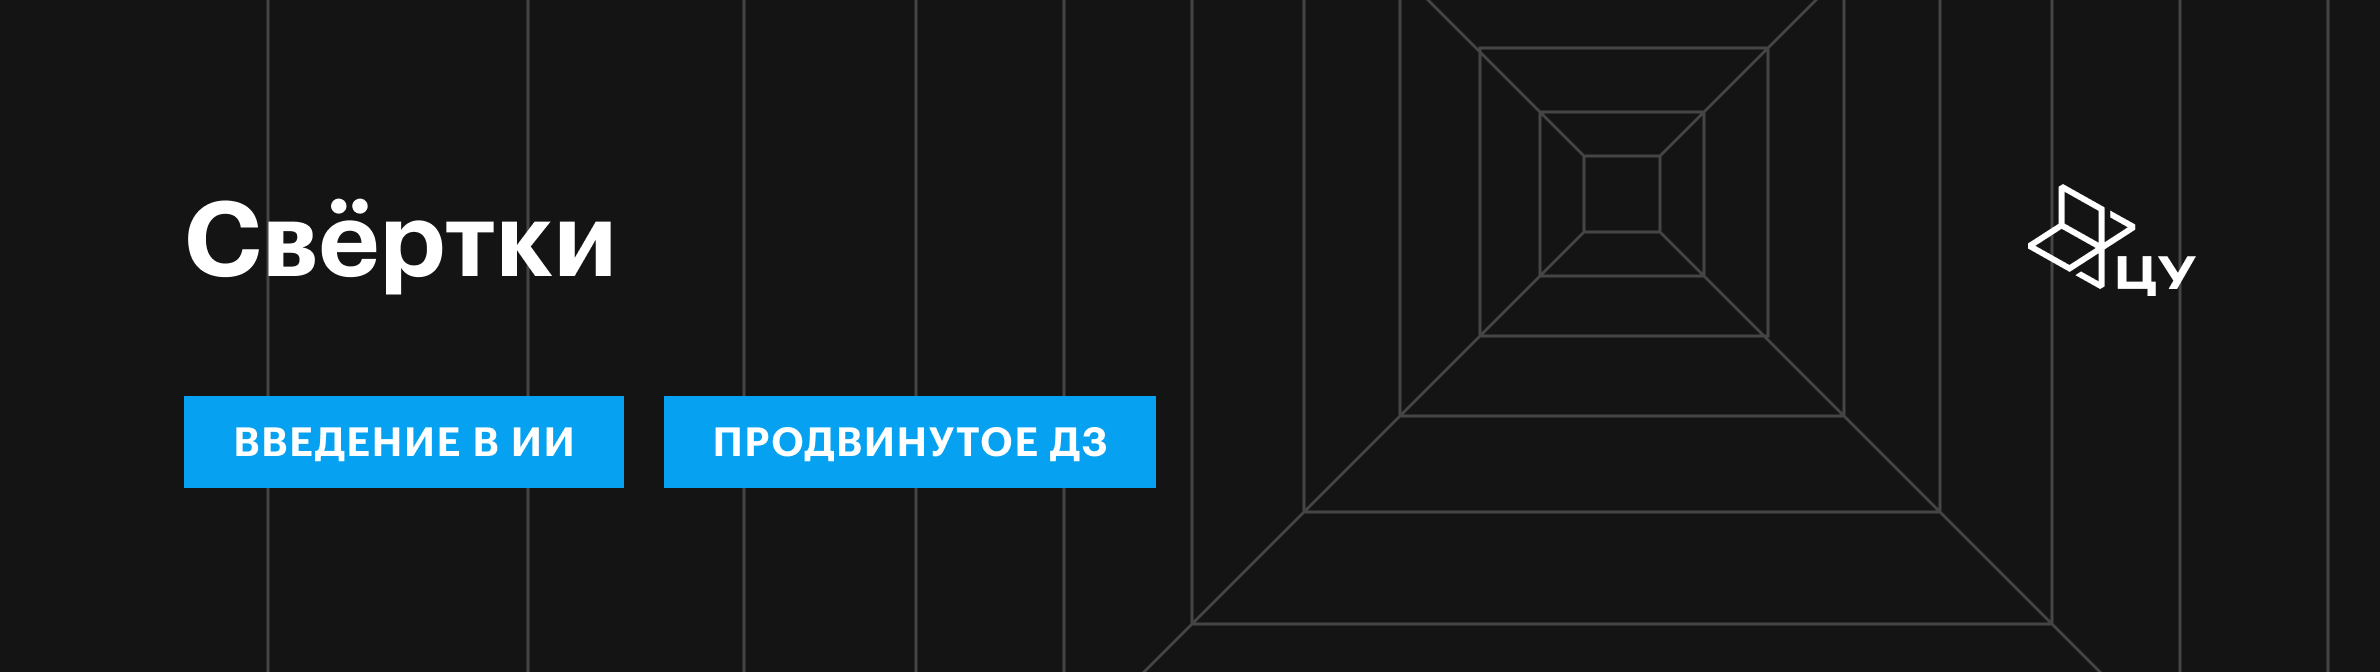

# Домашнее задание по теме «Свёртки»

В этом задании ты научишься использовать градиентные фильтры, пулинг (pooling) и морфологические операции для поиска структуры таблицы на изображении. Ты также сравнишь несколько подходов и разберёшься в их ограничениях.






> ### Правила домашнего задания
>1. Нельзя удалять существующие ячейки кода.
>
>2. Можно добавлять и дописывать свои ячейки.
>
>3. Место, куда тебе нужно написать код, помечается комментарием `# Напиши код здесь`.
>
> 4. После каждого задания старайся коротко интерпретировать результат, а не только получать числа.
>
> 5. Все ячейки должны запускаться последовательно сверху вниз. У проверяющих должна быть возможность воспроизвести все полученные результаты.
>
> 6. Ответ без кода, который подтвердит твоё решение, не засчитывается. Исключение — задачи и вопросы, где код не требуется и нужно сделать вывод из известных данных.

In [1]:

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["image.cmap"] = "gray"
plt.rcParams["axes.grid"] = False


## Вспомогательные функции и подготовка данных


In [2]:
# @title Вспомогательные функции
def show_images(images, titles=None, cmaps=None, ncols=None, figsize=None, vmin=None, vmax=None):
    n = len(images)
    if titles is None:
        titles = [""] * n
    if cmaps is None:
        cmaps = [None] * n
    if ncols is None:
        ncols = min(n, 4)
    nrows = int(np.ceil(n / ncols))

    if figsize is None:
        figsize = (4 * ncols, 3.5 * nrows)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for ax, image, title, cmap in zip(axes, images, titles, cmaps):
        arr = np.asarray(image)
        if cmap is None and arr.ndim == 2:
            cmap = "gray"
        ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def normalize01(x):
    x = np.asarray(x, dtype=float)
    mn, mx = x.min(), x.max()
    if mx - mn < 1e-12:
        return np.zeros_like(x)
    return (x - mn) / (mx - mn)


def mask_metrics(y_true, y_pred):
    y_true = (np.asarray(y_true) > 0).astype(np.uint8).ravel()
    y_pred = (np.asarray(y_pred) > 0).astype(np.uint8).ravel()

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    precision = tp / (tp + fp + 1e-12)
    recall = tp / (tp + fn + 1e-12)
    f1 = 2 * precision * recall / (precision + recall + 1e-12)

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }



def box_center(box):
    x, y, w, h = box
    return x + w / 2.0, y + h / 2.0


def point_in_box(point, box, margin=0):
    px, py = point
    x, y, w, h = box
    return (x - margin) <= px <= (x + w + margin) and (y - margin) <= py <= (y + h + margin)


def match_boxes_by_center(gt_boxes, pred_boxes, margin=3):
    used = set()
    matched = 0

    for gt in gt_boxes:
        gx, gy = box_center(gt)
        best_j = None
        best_dist = float("inf")

        for j, pred in enumerate(pred_boxes):
            if j in used:
                continue

            pc = box_center(pred)
            if not point_in_box(pc, gt, margin=margin):
                continue

            dist = (pc[0] - gx) ** 2 + (pc[1] - gy) ** 2
            if dist < best_dist:
                best_dist = dist
                best_j = j

        if best_j is not None:
            used.add(best_j)
            matched += 1

    precision = matched / max(len(pred_boxes), 1)
    recall = matched / max(len(gt_boxes), 1)
    f1 = 2 * precision * recall / (precision + recall + 1e-12)

    return {
        "matched": matched,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


def draw_boxes(gray, boxes, color=(0, 255, 0), thickness=2, extra_boxes=None, extra_color=(255, 0, 0)):
    if gray.ndim == 2:
        canvas = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
    else:
        canvas = gray.copy()

    if extra_boxes is not None:
        for x, y, w, h in extra_boxes:
            cv2.rectangle(canvas, (x, y), (x + w, y + h), extra_color, thickness)

    for x, y, w, h in boxes:
        cv2.rectangle(canvas, (x, y), (x + w, y + h), color, thickness)

    return canvas


def make_table_document(rows=5, cols=4, h=420, w=620, variant="clean", seed=42):
    rng = np.random.default_rng(seed)

    yy, xx = np.mgrid[0:h, 0:w]
    background = 228 + 10 * np.sin(xx / 47) + 8 * np.cos(yy / 63)
    img = np.clip(background, 170, 255).astype(np.uint8)

    x0, y0 = 70, 65
    col_widths = np.array([105, 130, 95, 120])[:cols]
    row_heights = np.array([44, 56, 48, 60, 52])[:rows]

    xs = [x0]
    for cw in col_widths:
        xs.append(xs[-1] + int(cw))

    ys = [y0]
    for rh in row_heights:
        ys.append(ys[-1] + int(rh))

    table_mask = np.zeros((h, w), dtype=np.uint8)
    h_mask = np.zeros((h, w), dtype=np.uint8)
    v_mask = np.zeros((h, w), dtype=np.uint8)

    line_thickness = 2
    for y in ys:
        cv2.line(table_mask, (xs[0], y), (xs[-1], y), 255, line_thickness)
        cv2.line(h_mask, (xs[0], y), (xs[-1], y), 255, line_thickness)

    for x in xs:
        cv2.line(table_mask, (x, ys[0]), (x, ys[-1]), 255, line_thickness)
        cv2.line(v_mask, (x, ys[0]), (x, ys[-1]), 255, line_thickness)

    cell_boxes = []
    for r in range(rows):
        for c in range(cols):
            x1 = xs[c] + line_thickness
            y1 = ys[r] + line_thickness
            cell_boxes.append((x1, y1, col_widths[c] - line_thickness, row_heights[r] - line_thickness))

    cv2.rectangle(img, (x0 - 18, y0 - 20), (xs[-1] + 18, ys[-1] + 20), 245, -1)

    dark = 40 if variant == "clean" else 52
    for y in ys:
        cv2.line(img, (xs[0], y), (xs[-1], y), dark, line_thickness)
    for x in xs:
        cv2.line(img, (x, ys[0]), (x, ys[-1]), dark, line_thickness)

    headers = ["Date", "Item", "Qty", "Price"][:cols]
    for c, title in enumerate(headers):
        cv2.putText(
            img, title, (xs[c] + 8, ys[0] + 28),
            cv2.FONT_HERSHEY_SIMPLEX, 0.55, 90, 1, cv2.LINE_AA
        )

    rows_text = [
        ["12/03", "milk", "2", "5.40"],
        ["13/03", "bread", "1", "2.10"],
        ["13/03", "apple", "6", "4.90"],
        ["14/03", "coffee", "1", "8.70"],
        ["15/03", "tea", "3", "6.00"],
    ]

    for r in range(1, rows):
        for c in range(cols):
            text = rows_text[(r - 1) % len(rows_text)][c]
            x1, y1, cw, ch = cell_boxes[r * cols + c]
            cv2.putText(
                img, text, (x1 + 7, y1 + ch // 2 + 6),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, 95, 1, cv2.LINE_AA
            )

    cv2.putText(img, "Invoice #1742", (80, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.8, 85, 2, cv2.LINE_AA)
    cv2.putText(img, "Customer: Demo Store", (80, 390), cv2.FONT_HERSHEY_SIMPLEX, 0.6, 100, 1, cv2.LINE_AA)

    if variant in ("hard", "noisy"):
        gaps = [
            ((xs[1] - 1, ys[2] - 1), (xs[1] + 1, ys[2] + 32)),
            ((xs[2] - 1, ys[3] - 28), (xs[2] + 1, ys[3] + 5)),
            ((xs[0] + 135, ys[1] - 1), (xs[0] + 165, ys[1] + 1)),
            ((xs[2] + 30, ys[4] - 1), (xs[2] + 58, ys[4] + 1)),
        ]

        for (x1, y1), (x2, y2) in gaps:
            img[max(0, y1):min(h, y2 + 1), max(0, x1):min(w, x2 + 1)] = 242

        illumination = 18 * (xx / w) + 10 * np.sin((yy + xx) / 90)
        img = np.clip(img + illumination, 0, 255)
        img = cv2.GaussianBlur(img.astype(np.uint8), (5, 5), 0.8)

        noise_sigma = 8 if variant == "hard" else 14
        noise = rng.normal(0, noise_sigma, size=img.shape)
        img = np.clip(img.astype(float) + noise, 0, 255).astype(np.uint8)

    if variant == "shadow":
        shadow = 35 * np.exp(-((xx - (x0 + 0.75 * (xs[-1] - xs[0]))) ** 2) / (2 * 90 ** 2))
        img = np.clip(img.astype(float) - shadow, 0, 255).astype(np.uint8)
        img = cv2.GaussianBlur(img, (3, 3), 0.5)

    return {
        "image": img,
        "table_mask": table_mask,
        "h_mask": h_mask,
        "v_mask": v_mask,
        "table_bbox": (xs[0], ys[0], xs[-1] - xs[0], ys[-1] - ys[0]),
        "cell_boxes": cell_boxes,
        "xs": xs,
        "ys": ys,
    }


dataset = {
    "clean": make_table_document(variant="clean"),
    "shadow": make_table_document(variant="shadow"),
    "hard": make_table_document(variant="hard"),
}


### Данные

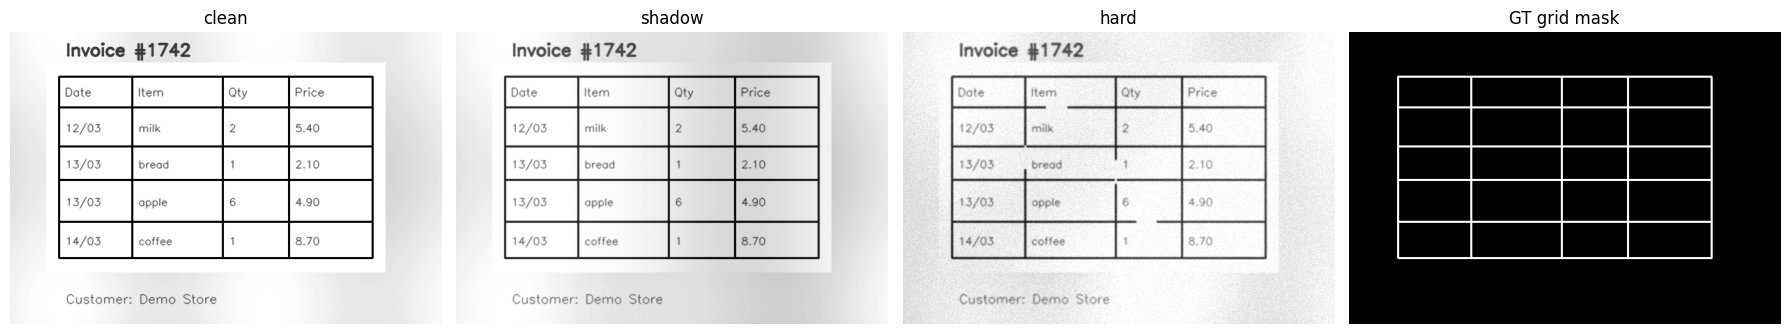

In [3]:

show_images(
    [
        dataset["clean"]["image"],
        dataset["shadow"]["image"],
        dataset["hard"]["image"],
        dataset["clean"]["table_mask"],
    ],
    titles=[
        "clean",
        "shadow",
        "hard",
        "GT grid mask",
    ],
    ncols=4,
    figsize=(18, 4),
)


## Задание 1. Поиск линий таблицы по одномерным профилям [3 балла]

В семинаре тебе приходилось работать с градиентными фильтрами, оператором Собеля и пулингом на отдельных изображениях.

Теперь эти идеи нужно собрать в небольшой прикладной pipeline: **по изображению документа определить, где проходят горизонтальные и вертикальные линии таблицы**.

Для этого выполни следующие действия.
1. **[0,8 баллa]** Реализуй `edge_maps(gray, operator)`, которая возвращает:
   - отклик на горизонтальные линии;
   - отклик на вертикальные линии.

2. **[0,7 балла]** Реализуй `line_profile(response, axis, pool_len=None)`:
   - для горизонтальных линий построй профиль по оси `y`;
   - для вертикальных — по оси `x`;
   - если `pool_len != None`, сначала усредни отклик **вдоль направления линии**.

3. **[0,6 балла]** Реализуй `find_peaks_1d(profile, min_distance, rel_height)`.

4. **[0,3 балла]** На изображении `hard` сравни три конфигурации:
   - `simple`, без pooling;
   - `sobel`, без pooling;
   - `sobel`, с pooling.

5. **[0,3 балла]** Для каждой конфигурации посчитай:
   - `hit_h`, `hit_v` — долю правильно найденных горизонтальных и вертикальных линий;
   - `mae_h`, `mae_v` — среднюю абсолютную ошибку по найденным линиям.

6. **[0,3 балла]** Покажи на изображении линии, найденные лучшей конфигурацией, и коротко объясни, почему она работает лучше.

При решении этой задачи используй следующие вспомогательные функции из начала ноутбука:

- `show_images(...)`,
- `normalize01(...)`.

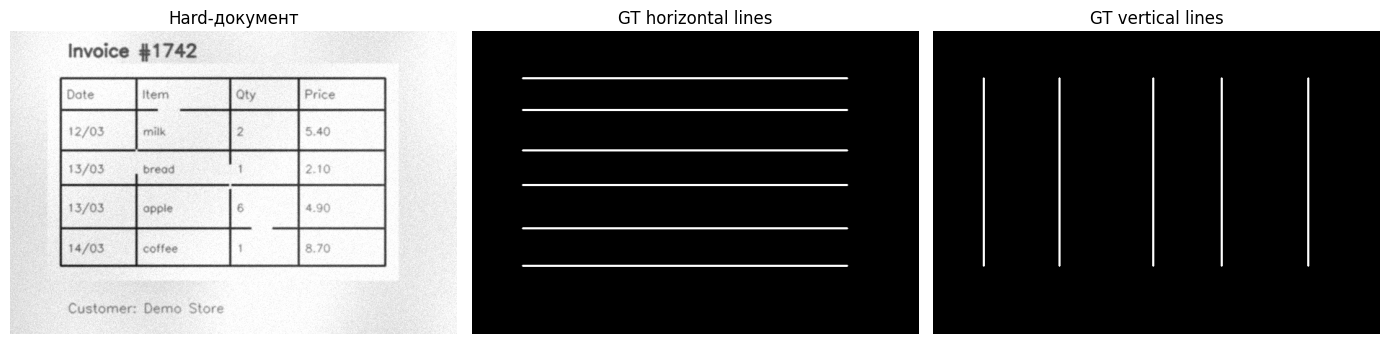

In [4]:

sample = dataset["hard"]

show_images(
    [sample["image"], sample["h_mask"], sample["v_mask"]],
    titles=["Hard-документ", "GT horizontal lines", "GT vertical lines"],
    ncols=3,
    figsize=(14, 4),
)


Вкратце, реализуй:
- `edge_maps(gray, operator="simple")`,
- `line_profile(response, axis="h", pool_len=None)`,
- `find_peaks_1d(profile, min_distance=25, rel_height=0.45)`.

После этого:  
1\) сравни три конфигурации из условия;  
2\) собери итоговую таблицу с `hit_h`, `hit_v`, `mae_h`, `mae_v`;  
3\) покажи лучшую конфигурацию на изображении `hard`.

In [5]:
from scipy.ndimage import convolve, correlate

In [6]:
def edge_maps(gray, operator="simple"):
    gray = gray.astype(float)

    if operator == "simple":
        kernel_x = np.array([[-1, 1]])
        kernel_y = np.array([[-1], [1]])
    else:
        kernel_x = np.array([
            [-1, 0, 1],
            [-2, 0, 2],
            [-1, 0, 1]
        ])
        kernel_y = np.array([
            [-1, -2, -1],
            [ 0,  0,  0],
            [ 1,  2,  1]
        ])

    resp_x = np.abs(convolve(gray, kernel_x))
    resp_y = np.abs(convolve(gray, kernel_y))

    return resp_y, resp_x

from scipy.ndimage import uniform_filter

def line_profile(response, axis='h', pool_len=None):
    resp = response.copy()
    if axis == 'h':
      axis = 1
    else:
      axis = 0

    if pool_len is not None:
        if axis == 1:
            resp = uniform_filter(resp, size=(1, pool_len))
        elif axis == 0:
            resp = uniform_filter(resp, size=(pool_len, 1))

    profile = resp.mean(axis=axis)

    return profile


def find_peaks_1d(profile, min_distance=25, rel_height=0.45):
    profile = np.asarray(profile)

    maxx = profile.max()

    thr = maxx * rel_height
    peak = []
    for i in range(1, len(profile) - 1):
      if profile[i] > thr and profile[i] >= profile[i - 1] and profile[i] >= profile[i + 1]:
        peak.append(i)

    res = []
    for i in peak:
      p = profile[i]
      if len(res) == 0:
        res.append(i)
      else:
        if i - res[-1] >= min_distance:
          res.append(i)
        else:
          if p > profile[res[-1]]:
            res[-1] = i
    return res

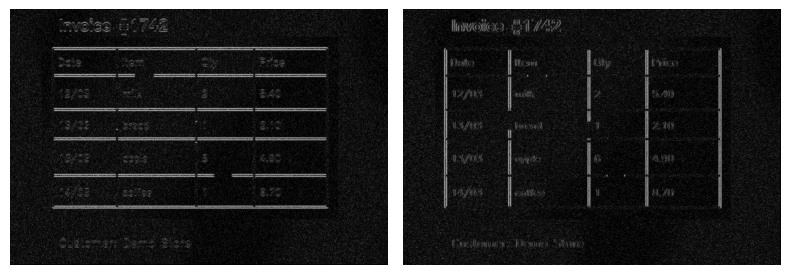

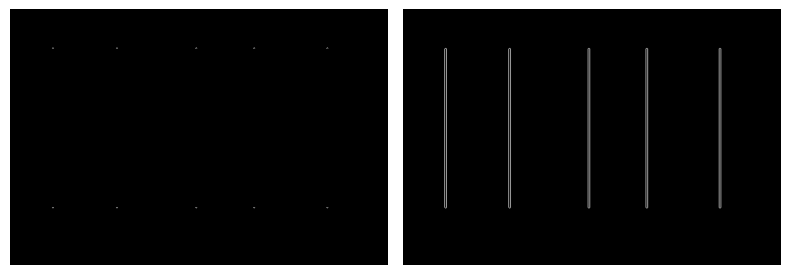

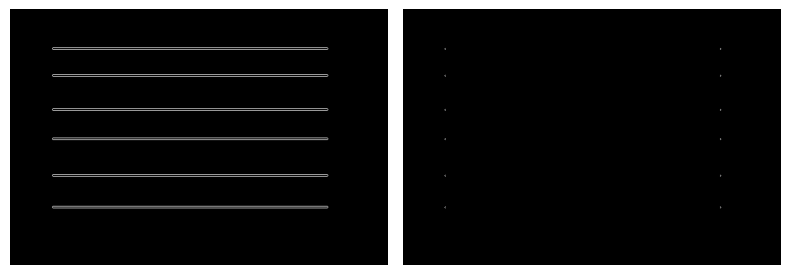

In [7]:
show_images(edge_maps(sample['image']))
show_images(edge_maps(sample['v_mask']))
show_images(edge_maps(sample['h_mask']))

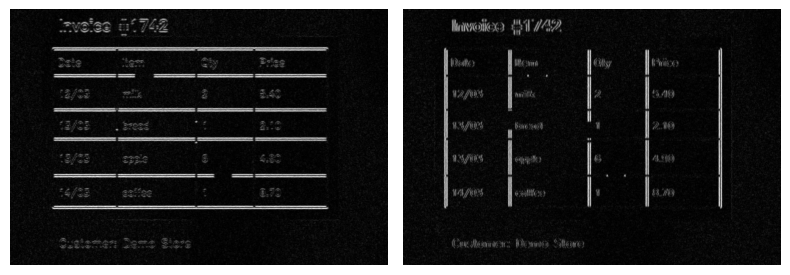

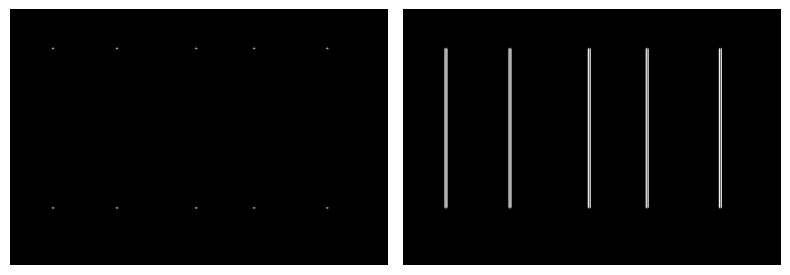

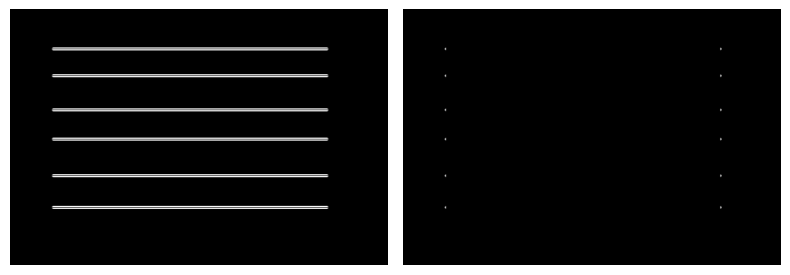

In [8]:
show_images(edge_maps(sample['image'], 'sobel'))
show_images(edge_maps(sample['v_mask'], 'sobel'))
show_images(edge_maps(sample['h_mask'], 'sobel'))

In [9]:
def hit_mae(gt, pred):
    used_pred = []
    errors = []

    for g in gt:
        candidates = []
        for j, p in enumerate(pred):
            if j not in used_pred:
                candidates.append((abs(p - g), j, p))

        if len(candidates) == 0:
            continue

        err, best_j, best_p = min(candidates, key=lambda x: x[0])
        used_pred.append(best_j)
        errors.append(err)

    hit = len(used_pred) / max(len(gt), 1)
    mae = np.mean(errors)
    return hit, mae

In [10]:
gt_y = sample["ys"]
gt_x = sample["xs"]

configs = [
    {"name": "simple / no pooling", "operator": "simple", "pool_len": None},
    {"name": "sobel / no pooling",  "operator": "sobel",  "pool_len": None},
    {"name": "sobel / pooling",     "operator": "sobel",  "pool_len": 31},
]

results = []

for cfg in configs:
    response_h, response_v = edge_maps(sample["image"], operator=cfg["operator"])

    profile_h = line_profile(response_h, axis="h", pool_len=cfg["pool_len"])
    profile_v = line_profile(response_v, axis="v", pool_len=cfg["pool_len"])

    pred_y = find_peaks_1d(profile_h)
    pred_x = find_peaks_1d(profile_v)

    hit_h, mae_h = hit_mae(gt_y, pred_y)
    hit_v, mae_v = hit_mae(gt_x, pred_x)

    results.append({
        "config": cfg["name"],
        "hit_h": hit_h,
        "hit_v": hit_v,
        "mae_h": mae_h,
        "mae_v": mae_v,
        "pred_h_lines": pred_y,
        "pred_v_lines": pred_x,
    })

results_df = pd.DataFrame(results)
display(results_df[["config", "hit_h", "hit_v", "mae_h", "mae_v"]])

,config,hit_h,hit_v,mae_h,mae_v
0,simple / no pooling,1.0,1.0,1.833333,1.2
1,sobel / no pooling,1.0,1.0,2.000000,2.0
2,sobel / pooling,1.0,1.0,2.000000,2.0


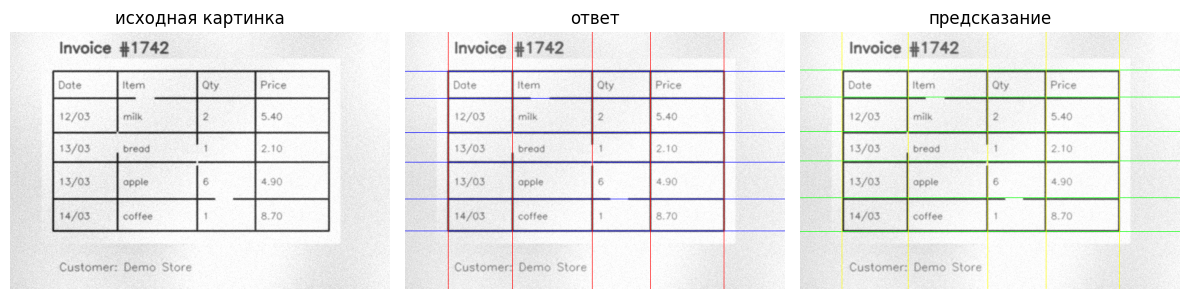

In [11]:
canvas1 = cv2.cvtColor(sample["image"], cv2.COLOR_GRAY2RGB)
canvas2 = cv2.cvtColor(sample["image"], cv2.COLOR_GRAY2RGB)

pred_y = results_df.loc[0, "pred_h_lines"]
pred_x = results_df.loc[0, "pred_v_lines"]

for y in gt_y:
    cv2.line(canvas1, (0, y), (canvas1.shape[1] - 1, y), (0, 0, 255))
for x in gt_x:
    cv2.line(canvas1, (x, 0), (x, canvas1.shape[0] - 1), (255, 0, 0))

for y in pred_y:
    cv2.line(canvas2, (0, y), (canvas2.shape[1] - 1, y), (0, 255, 0))
for x in pred_x:
    cv2.line(canvas2, (x, 0), (x, canvas2.shape[0] - 1), (255, 255, 0))

show_images([sample["image"], canvas1, canvas2], titles=["исходная картинка", f"ответ", f"предсказание"])

лучшей оказалась простая конфигурация. но так как все конфигурации отработали почти одинаково, разница скорее всего оказалась на уровне допустимой погрешности, поэтому все варианты подходят

### Самопроверка

Ячейку кода ниже можно запускать после того, как тебе удалось реализовать `edge_maps`, `line_profile` и `find_peaks_1d`.  
Проверка использует маленькие искусственные примеры и смотрит, что базовая логика работает правильно:

- горизонтальная полоса должна сильнее проявляться в `response_h`;
- вертикальная полоса — в `response_v`;
- одномерный профиль должен иметь максимум в ожидаемой строке/колонке;
- детектор пиков должен находить заранее известные локальные максимумы.

In [12]:
# Asserts для задания 1

toy_h = np.zeros((21, 21), dtype=np.uint8)
toy_h[9:12, :] = 255
response_h, response_v = edge_maps(toy_h, operator="simple")

print(response_h.shape, toy_h.shape)
print(response_h.sum(), response_v.sum())

assert response_h.shape == toy_h.shape
assert response_v.shape == toy_h.shape
assert response_h.sum() > 5 * (response_v.sum() + 1e-6), "Для горизонтальной полосы response_h должен доминировать."

toy_v = np.zeros((21, 21), dtype=np.uint8)
toy_v[:, 9:12] = 255
response_h2, response_v2 = edge_maps(toy_v, operator="simple")

assert response_h2.shape == toy_v.shape
assert response_v2.shape == toy_v.shape
assert response_v2.sum() > 5 * (response_h2.sum() + 1e-6), "Для вертикальной полосы response_v должен доминировать."

resp_rows = np.zeros((10, 12), dtype=np.float32)
resp_rows[2, :] = 5
resp_rows[7, :] = 8
profile_h = line_profile(resp_rows, axis="h")
assert len(profile_h) == resp_rows.shape[0]
assert int(np.argmax(profile_h)) == 7, "Профиль по строкам должен иметь максимум в строке 7."

resp_cols = np.zeros((10, 12), dtype=np.float32)
resp_cols[:, 3] = 4
resp_cols[:, 8] = 9
profile_v = line_profile(resp_cols, axis="v")
assert len(profile_v) == resp_cols.shape[1]
assert int(np.argmax(profile_v)) == 8, "Профиль по столбцам должен иметь максимум в колонке 8."

toy_profile = np.array([0, 1, 4, 1, 0, 0, 5, 1, 0], dtype=np.float32)
peaks = find_peaks_1d(toy_profile, min_distance=2, rel_height=0.5)
assert peaks == [2, 6], f"Ожидались пики [2, 6], а получено {peaks}"

print("Самопроверка для задания 1 пройдена.")

(21, 21) (21, 21)
10710.0 0.0
Самопроверка для задания 1 пройдена.


In [13]:
resp_h, resp_v = edge_maps(sample['image'])
prof_v = line_profile(resp_v)
find_peaks_1d(prof_v, min_distance=25)

[32, 88, 139, 189, 245, 302, 347, 384, 410]

## Задание 2. Выделение сетки таблицы через морфологию [3 балла]

В продвинутом семинаре морфология использовалась для работы с текстом.  
Здесь мы переносим идею в новую постановку: выделить **именно сетку таблицы**, а не текст.

Что нужно сделать:

1. **[0,5 балла]** Реализуй `binarize_otsu_inverse(gray)`:
   - слегка сгладь изображение;
   - примени обратный порог Оцу, чтобы тёмные линии и текст стали белыми.

2. **[1,5 балла]** Реализуй `extract_table_lines_morph(binary_inv, h_len, v_len, close_len=17)`:
   - через `opening` с горизонтальным ядром выдели горизонтальные линии;
   - через `opening` с вертикальным ядром выдели вертикальные линии;
   - при необходимости доработай результат через `closing`;
   - объедини горизонтальную и вертикальную маски в одну grid-mask.

3. **[0,5 балла]** На `hard`-изображении сравни три режима и напиши короткий вывод:
   - `short` — слишком короткие ядра;
   - `good` — разумный масштаб;
   - `too_long` — слишком длинные ядра.

4. **[0,5 балла]** Для каждого режима посчитай `f1_h`, `f1_v`, `f1_grid`.

При решении этой задачи используй следующие вспомогательные функции из начала ноутбука:

- `show_images(...)`,
- `mask_metrics(...)`.



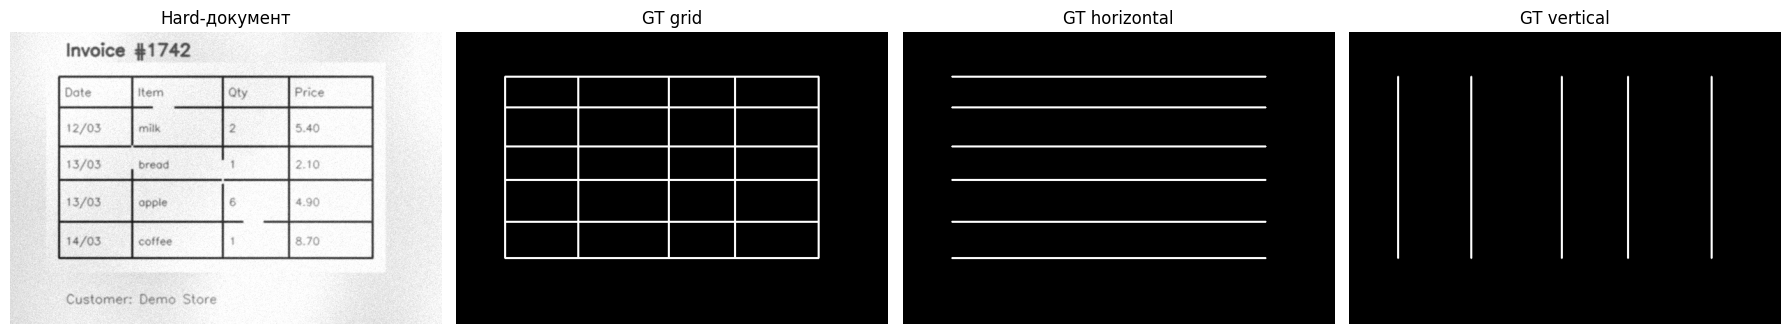

In [14]:

sample = dataset["hard"]

show_images(
    [sample["image"], sample["table_mask"], sample["h_mask"], sample["v_mask"]],
    titles=["Hard-документ", "GT grid", "GT horizontal", "GT vertical"],
    ncols=4,
    figsize=(18, 4),
)


Вкратце, реализуй:
- `binarize_otsu_inverse(gray)`,
- `extract_table_lines_morph(binary_inv, h_len, v_len, close_len=17)`.

После этого сравни три режима (`short`, `good`, `too_long`) на `hard`-изображении.


In [15]:

def binarize_otsu_inverse(gray):
    gray = cv2.GaussianBlur(gray, (5, 5), 0)
    _, page_binary = cv2.threshold(
      gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )
    return page_binary


def extract_table_lines_morph(binary_inv, h_len, v_len, close_len=17):
    kernel_h = cv2.getStructuringElement(cv2.MORPH_RECT, (h_len, 1))
    kernel_v = cv2.getStructuringElement(cv2.MORPH_RECT, (1, v_len))
    close_h = cv2.getStructuringElement(cv2.MORPH_RECT, (close_len, 1))
    close_v = cv2.getStructuringElement(cv2.MORPH_RECT, (1, close_len))

    h_mask = cv2.morphologyEx(binary_inv, cv2.MORPH_OPEN, kernel_h)
    v_mask = cv2.morphologyEx(binary_inv, cv2.MORPH_OPEN, kernel_v)

    h_mask = cv2.morphologyEx(h_mask, cv2.MORPH_CLOSE, close_h)
    v_mask = cv2.morphologyEx(v_mask, cv2.MORPH_CLOSE, close_v)

    grid_mask = cv2.bitwise_or(h_mask, v_mask)

    return h_mask, v_mask, grid_mask

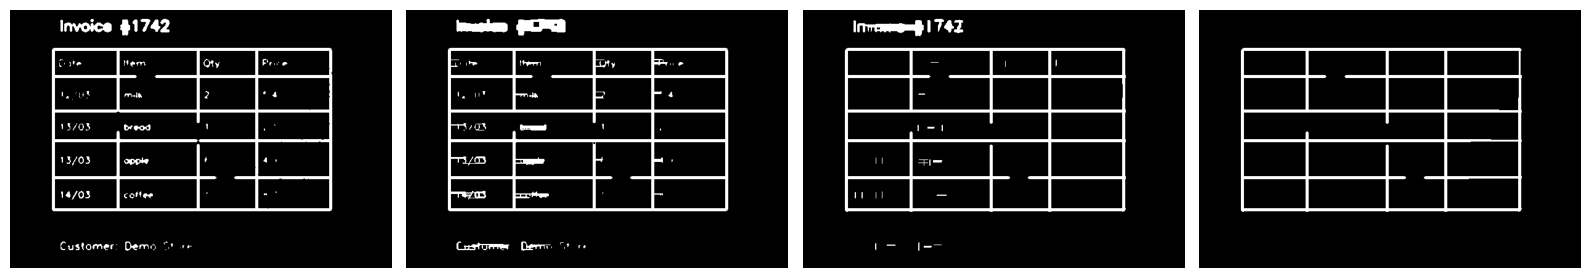

height check
 short
  0.4881522406380539
 good
  0.6877432748027617
 long
  0.7502712903982058
vertical check
 short
  0.2758671695878
 good
  0.6369383222274714
 long
  0.7396091657568895
grid check
 short
  0.618849805782906
 good
  0.6902612254720346
 long
  0.7539776462848632


In [16]:
img = binarize_otsu_inverse(sample['image'])

short_h, short_v, short_grid = extract_table_lines_morph(img, 3, 3, 11)
good_h, good_v, good_grid = extract_table_lines_morph(img, 10, 10, 17)
long_h, long_v, long_grid = extract_table_lines_morph(img, 40, 40, 17)
show_images((img, short_grid, good_grid, long_grid))

print("height check")
for i, mode in enumerate([short_h, good_h, long_h]):
  if i == 0:
    print(" short")
  elif i == 1:
    print(" good")
  else:
    print(" long")
  print(f"  {mask_metrics(sample['h_mask'], mode)['f1']}")
print("vertical check")
for i, mode in enumerate([short_v, good_v, long_v]):
  if i == 0:
    print(" short")
  elif i == 1:
    print(" good")
  else:
    print(" long")
  print(f"  {mask_metrics(sample['v_mask'], mode)['f1']}")
print("grid check")
for i, mode in enumerate([short_grid, good_grid, long_grid]):
  if i == 0:
    print(" short")
  elif i == 1:
    print(" good")
  else:
    print(" long")
  print(f"  {mask_metrics(sample['table_mask'], mode)['f1']}")


### Самопроверка

Эта проверка помогает убедиться:

- что `binarize_otsu_inverse` действительно возвращает бинарную инвертированную маску;
- `extract_table_lines_morph` умеет выделять горизонтальные и вертикальные линии на простом контролируемом примере и не разваливается из-за небольшого шума.

In [17]:
# Asserts для задания 2

toy_gray = np.full((40, 40), 220, dtype=np.uint8)
toy_gray[:, :18] = 30

binary_inv = binarize_otsu_inverse(toy_gray)
unique_values = set(np.unique(binary_inv).tolist())

assert binary_inv.shape == toy_gray.shape
assert unique_values.issubset({0, 255}), f"Ожидалась бинарная маска из 0/255, получено {unique_values}"
assert binary_inv[:, :18].mean() > 200, "Тёмная область должна стать белой после inverse-binarization."
assert binary_inv[:, 22:].mean() < 50, "Светлая область должна остаться чёрной."

toy_binary = np.zeros((100, 120), dtype=np.uint8)
gt_h = np.zeros_like(toy_binary)
gt_v = np.zeros_like(toy_binary)
gt_grid = np.zeros_like(toy_binary)

for y in [20, 50, 80]:
    cv2.line(toy_binary, (15, y), (105, y), 255, 2)
    cv2.line(gt_h, (15, y), (105, y), 255, 2)
    cv2.line(gt_grid, (15, y), (105, y), 255, 2)

for x in [15, 60, 105]:
    cv2.line(toy_binary, (x, 20), (x, 80), 255, 2)
    cv2.line(gt_v, (x, 20), (x, 80), 255, 2)
    cv2.line(gt_grid, (x, 20), (x, 80), 255, 2)

# Добавим немного шума, который хороший morph-pipeline должен отбросить.
cv2.rectangle(toy_binary, (5, 5), (9, 9), 255, -1)
cv2.rectangle(toy_binary, (110, 90), (114, 94), 255, -1)

h_pred, v_pred, grid_pred = extract_table_lines_morph(
    toy_binary,
    h_len=25,
    v_len=20,
    close_len=9,
)

metrics_h = mask_metrics(gt_h, h_pred)
metrics_v = mask_metrics(gt_v, v_pred)
metrics_grid = mask_metrics(gt_grid, grid_pred)

assert metrics_h["f1"] > 0.95, f"Слишком слабое выделение горизонталей: {metrics_h}"
assert metrics_v["f1"] > 0.95, f"Слишком слабое выделение вертикалей: {metrics_v}"
assert metrics_grid["f1"] > 0.95, f"Слишком слабое выделение grid-mask: {metrics_grid}"

print("Самопроверка для задания 2 пройдена.")

Самопроверка для задания 2 пройдена.


## Задание 3. От grid-mask к ячейкам таблицы [4 балла]

В продвинутом семинаре был раздел про connected components после морфологии.  
Здесь мы делаем следующий шаг: переходим от выделенной сетки таблицы к **структуре ячеек**.

Выполни следующие действия.

1. **[2 балла]** Реализуй `extract_cells_from_grid(grid_mask, min_area=1500)`:
   - найди основную компоненту сетки таблицы;
   - ограничь область поиска `bounding box`'ом этой компоненты;
   - инвертируй `grid_mask` внутри таблицы;
   - найди connected components;
   - отбрось фон и слишком маленькие компоненты;
   - верни список найденных ячеек в формате `(x, y, w, h)`.

2. **[0,5 балла]** Оцени качество восстановления ячеек на трёх вариантах документа:
   - `clean`,
   - `shadow`,
   - `hard`.

3. **[1 балл]** Для каждого варианта посчитай:
   - `pred_cells`,
   - `gt_cells`,
   - `matched`,
   - `precision`, `recall`, `f1`.

Совпадение считаем простым правилом:  **предсказанная ячейка считается правильной, если её центр попал внутрь соответствующей ground truth ячейки** (с one-to-one matching, чтобы одну истинную ячейку нельзя было засчитать несколько раз).

4. **[0,5 балла]** Коротко проанализировать, где и почему pipeline ломается.



При решении этой задачи используй следующие вспомогательные функции из начала ноутбука:

- `match_boxes_by_center(...)`,
- `draw_boxes(...)`,
- `show_images(...)`.

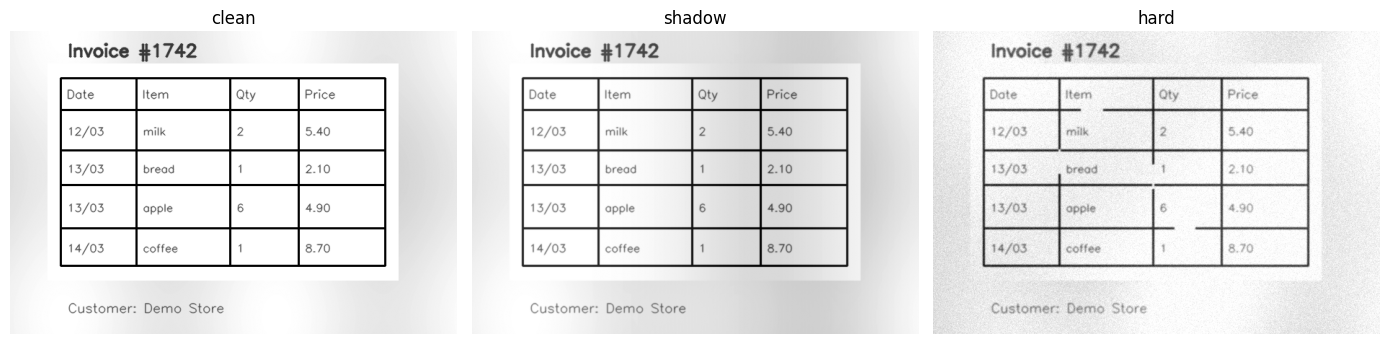

In [18]:

show_images(
    [dataset["clean"]["image"], dataset["shadow"]["image"], dataset["hard"]["image"]],
    titles=["clean", "shadow", "hard"],
    ncols=3,
    figsize=(14, 4),
)


Вкратце, реализуй `extract_cells_from_grid(grid_mask, min_area=1500)`.

После этого:  
1\) прогони полный pipeline на `clean`, `shadow`, `hard`;  
2\) сравни найденные ячейки с ground truth через `match_boxes_by_center`;  
3\) собери итоговую таблицу с объектными метриками.

In [55]:
def extract_cells_from_grid(grid_mask, min_area=1500):
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(grid_mask, connectivity=8)

    main_idx = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    x, y, w, h, _ = stats[main_idx]
    table_bbox = (x, y, w, h)

    roi = grid_mask[y:y+h, x:x+w]

    inv_roi = cv2.bitwise_not(roi)

    cell_mask = np.zeros_like(grid_mask)
    cell_mask[y:y+h, x:x+w] = inv_roi

    n_cells, cell_labels, cell_stats, _ = cv2.connectedComponentsWithStats(inv_roi, connectivity=8)

    pred_boxes = []

    for i in range(1, n_cells):
        cx, cy, cw, ch, area = cell_stats[i]

        if area < min_area:
            continue

        pred_boxes.append((x + cx, y + cy, cw, ch))

    return pred_boxes, cell_mask, table_bbox

In [56]:
pred_boxes, cell_mask, table_bbox = extract_cells_from_grid(long_grid)

array([[[238, 238, 238],
        [227, 227, 227],
        [242, 242, 242],
        ...,
        [255, 255, 255],
        [250, 250, 250],
        [255, 255, 255]],

       [[232, 232, 232],
        [236, 236, 236],
        [238, 238, 238],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[246, 246, 246],
        [227, 227, 227],
        [249, 249, 249],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [243, 243, 243]],

       ...,

       [[219, 219, 219],
        [220, 220, 220],
        [221, 221, 221],
        ...,
        [244, 244, 244],
        [249, 249, 249],
        [249, 249, 249]],

       [[207, 207, 207],
        [220, 220, 220],
        [223, 223, 223],
        ...,
        [247, 247, 247],
        [251, 251, 251],
        [245, 245, 245]],

       [[221, 221, 221],
        [234, 234, 234],
        [226, 226, 226],
        ...,
        [249, 249, 249],
        [245, 245, 245],
        [231, 231, 231]]], dtype=uint8)
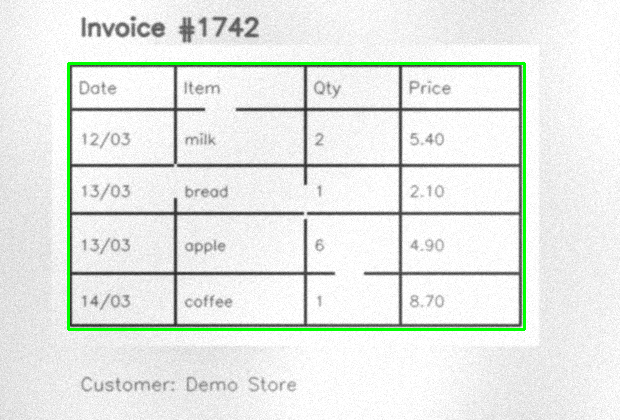

In [57]:
draw_boxes(sample['image'], [table_bbox])

array([[[238, 238, 238],
        [227, 227, 227],
        [242, 242, 242],
        ...,
        [255, 255, 255],
        [250, 250, 250],
        [255, 255, 255]],

       [[232, 232, 232],
        [236, 236, 236],
        [238, 238, 238],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[246, 246, 246],
        [227, 227, 227],
        [249, 249, 249],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [243, 243, 243]],

       ...,

       [[219, 219, 219],
        [220, 220, 220],
        [221, 221, 221],
        ...,
        [244, 244, 244],
        [249, 249, 249],
        [249, 249, 249]],

       [[207, 207, 207],
        [220, 220, 220],
        [223, 223, 223],
        ...,
        [247, 247, 247],
        [251, 251, 251],
        [245, 245, 245]],

       [[221, 221, 221],
        [234, 234, 234],
        [226, 226, 226],
        ...,
        [249, 249, 249],
        [245, 245, 245],
        [231, 231, 231]]], dtype=uint8)
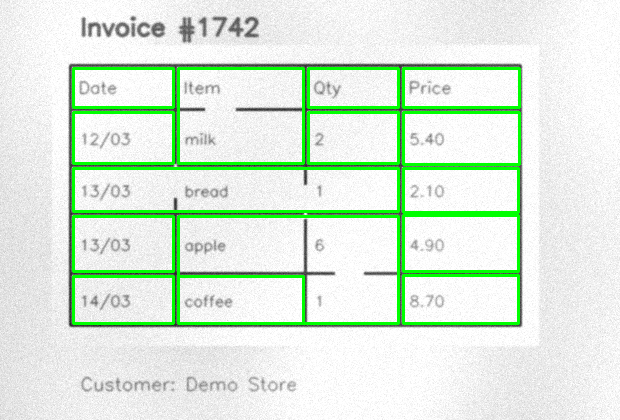

In [51]:
draw_boxes(sample['image'], pred_boxes)

### Самопроверка

Проверь `extract_cells_from_grid` на маленькой синтетической сетке 3 × 3.

Идея проверки:
- функция должна найти bounding box таблицы;
- внутри таблицы должны быть найдены все 9 ячеек;
- центры найденных прямоугольников должны попадать в соответствующие ground truth ячейки.

In [36]:
# Asserts для задания 3

toy_grid = np.zeros((140, 180), dtype=np.uint8)
xs = [20, 70, 120, 160]
ys = [15, 55, 95, 125]

for y in ys:
    cv2.line(toy_grid, (xs[0], y), (xs[-1], y), 255, 2)
for x in xs:
    cv2.line(toy_grid, (x, ys[0]), (x, ys[-1]), 255, 2)

pred_boxes, cell_mask, table_bbox = extract_cells_from_grid(toy_grid, min_area=150)

gt_boxes = []
line_thickness = 2
for r in range(len(ys) - 1):
    for c in range(len(xs) - 1):
        gt_boxes.append((
            xs[c] + line_thickness,
            ys[r] + line_thickness,
            xs[c + 1] - xs[c] - line_thickness,
            ys[r + 1] - ys[r] - line_thickness,
        ))

metrics = match_boxes_by_center(gt_boxes, pred_boxes, margin=2)

assert table_bbox is not None, "Должен быть найден bounding box таблицы."
assert len(pred_boxes) == 9, f"Ожидалось 9 ячеек, а получено {len(pred_boxes)}."
assert cell_mask.sum() > 0, "Маска внутренних областей не должна быть пустой."
assert metrics["matched"] == 9, f"Все 9 ячеек должны быть сопоставлены, а получено {metrics}."

print("Самопроверка для задания 3 пройдена.")

Самопроверка для задания 3 пройдена.


пайплайн кажется нигде не ломается